# Background ROI Playground

Use this notebook to explore background modeling in a chosen ROI.


## Notes

- ROI format is `(y0, y1, x0, x1)` (Python slicing: y1/x1 are exclusive).
- The widgets below update a red rectangle over the image and store the ROI in `roi_state["roi"]`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display
from astropy.io import fits

import sys
sys.path.append("..")

path = "../test-data/of9b05010_flt.fits"
# For HST FLT files, science data is typically in extension 1 (SCI)
# and DQ in extension 3.
data = fits.getdata(path, ext=1)
dq = fits.getdata(path, ext=3)


In [ ]:
# Provide your own 2D image data here (e.g., from a FITS file).
# If `data` is not defined yet, build a simple synthetic example.
try:
    data
except NameError:
    ny, nx = 200, 300
    yy, xx = np.indices((ny, nx))
    data = (
        10
        + 0.01 * xx
        + 0.02 * yy
        + 0.0001 * xx * yy
        + np.random.normal(0.0, 0.2, size=(ny, nx))
    )

data = np.asarray(data, dtype=float)


In [ ]:
def _show_roi(img, x_range, y_range, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
    x0, x1 = x_range
    y0, y1 = y_range
    rect = Rectangle(
        (x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", lw=2
    )
    ax.add_patch(rect)
    ax.set_title(f"ROI: y[{y0}:{y1}], x[{x0}:{x1}]")
    plt.show()


def make_roi_widgets(img):
    ny, nx = img.shape
    x_slider = widgets.IntRangeSlider(
        value=[0, max(1, nx // 3)],
        min=0,
        max=nx - 1,
        step=1,
        description="x",
        continuous_update=False,
    )
    y_slider = widgets.IntRangeSlider(
        value=[0, max(1, ny // 3)],
        min=0,
        max=ny - 1,
        step=1,
        description="y",
        continuous_update=False,
    )
    vmin = widgets.FloatText(value=float(np.nanpercentile(img, 5)), description="vmin")
    vmax = widgets.FloatText(value=float(np.nanpercentile(img, 95)), description="vmax")
    return x_slider, y_slider, vmin, vmax


roi_state = {"roi": None}

x_slider, y_slider, vmin_box, vmax_box = make_roi_widgets(np.cbrt(data))


def _update_roi(x, y, vmin, vmax):
    roi_state["roi"] = (y[0], y[1], x[0], x[1])
    _show_roi(data, x, y, vmin=vmin, vmax=vmax)


out = widgets.interactive_output(
    _update_roi,
    {"x": x_slider, "y": y_slider, "vmin": vmin_box, "vmax": vmax_box},
)

display(
    widgets.VBox([x_slider, y_slider, widgets.HBox([vmin_box, vmax_box])]), out
)


Output()

In [ ]:
# The current ROI selection (y0, y1, x0, x1):
roi = roi_state["roi"]
roi


(251, 553, 483, 760)

In [ ]:
# fix ROI for future use
roi = (251, 553, 483, 760) 

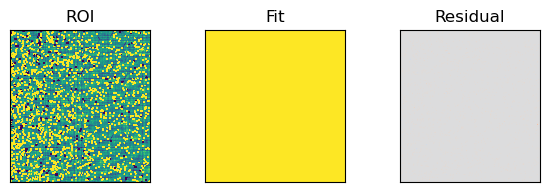

[ 8.05572889e-03 -1.20042930e-05 -1.45784743e-07 -5.42655513e-05
  1.42586067e-07  4.61876838e-07]
[[0.02580631 0.02560357 0.02540175 0.02520086 0.02500089]
 [0.02581837 0.02561577 0.02541409 0.02521334 0.02501352]
 [0.02583013 0.02562767 0.02542614 0.02522553 0.02502585]
 [0.0258416  0.02563929 0.0254379  0.02523743 0.02503789]
 [0.02585278 0.02565061 0.02544936 0.02524904 0.02504964]]
[[-0.03601565 -0.03557347 -0.03570049 -0.03540446 -0.03504503]
 [-0.03591873 -0.03516075  0.9609132  -0.03517211 -0.03480512]
 [-0.03570174 -0.03550224 -0.03546234 -0.0349313  -0.03482375]
 [-0.03600766 -0.03538616 -0.03516154 -0.03526673 -0.03473837]
 [-0.03638413 -0.03587169 -0.03567486 -0.03547302 -0.03511844]]


In [25]:
from utilities import fit_poly_surface_2d

# Fit polynomial surface on current ROI and plot data, fit, residual, mask
if roi_state["roi"] is None:
    raise ValueError("Select an ROI first using the sliders above.")

y0, y1, x0, x1 = roi_state["roi"]
roi_data = data[y0:y1, x0:x1]
roi_dq = dq[y0:y1, x0:x1]

flags = [1, 2, 4, 16, 32, 256, 512, 8192]
dq_mask = 0
for flag in flags:
    dq_mask |= flag
bad = (roi_dq & dq_mask) != 0

fit_result = fit_poly_surface_2d(data, (y0, y1, x0, x1), order=2, mask=bad)
fit = fit_result["model"]
resid = roi_data - fit

vmin = np.nanpercentile(roi_data, 5)
vmax = np.nanpercentile(roi_data, 95)

fig, axes = plt.subplots(1, 4, figsize=(6, 2))
axes[0].imshow(roi_data, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("ROI")
axes[1].imshow(fit, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Fit")
resid_limit = np.nanmax(np.abs(resid))
axes[2].imshow(resid, origin="lower", cmap="coolwarm", vmin=-resid_limit, vmax=resid_limit)
axes[2].set_title("Residual")
axes[3].imshow(bad, origin="lower", cmap="gray_r")
axes[3].set_title("DQ Mask")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
